In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [ ]:
df_train.head(10)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


In [ ]:
print(df_train.shape)
print(df_test.shape)

(120000, 3)
(7600, 3)


In [ ]:
df_train['Class Index'].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

### Text processing 

In [4]:
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '' , text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Merge title and description to create a more informative input text
# Apply the cleaning function

df_train['text'] = (df_train['Title'] + " " + df_train['Description'].apply(clean_text))
df_test['text'] = (df_test['Title'] + " " + df_test['Description'].apply(clean_text))

In [6]:
df_train.drop(columns = ['Title'], inplace = True)
df_test.drop(columns = ['Title'], inplace = True)

In [9]:
df_train

,Class Index,Description,text
0,3,"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
...,...,...,...
119995,1,KARACHI (Reuters) - Pakistani President Perve...,Pakistan's Musharraf Says Won't Quit as Army C...
119996,2,Red Sox general manager Theo Epstein acknowled...,Renteria signing a top-shelf deal red sox gene...
119997,2,The Miami Dolphins will put their courtship of...,Saban not going to Dolphins yet miami dolphin ...
119998,2,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...,Today's NFL games pittsburgh ny giant time pm ...


In [10]:
# Create mapping dictionary
class_mapping = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

# Replace numbers with names
df_train['category'] = df_train['Class Index'].map(class_mapping)

# Check
print(df_train[['Class Index', 'category']].head(10))

   Class Index  category
0            3  Business
1            3  Business
2            3  Business
3            3  Business
4            3  Business
5            3  Business
6            3  Business
7            3  Business
8            3  Business
9            3  Business


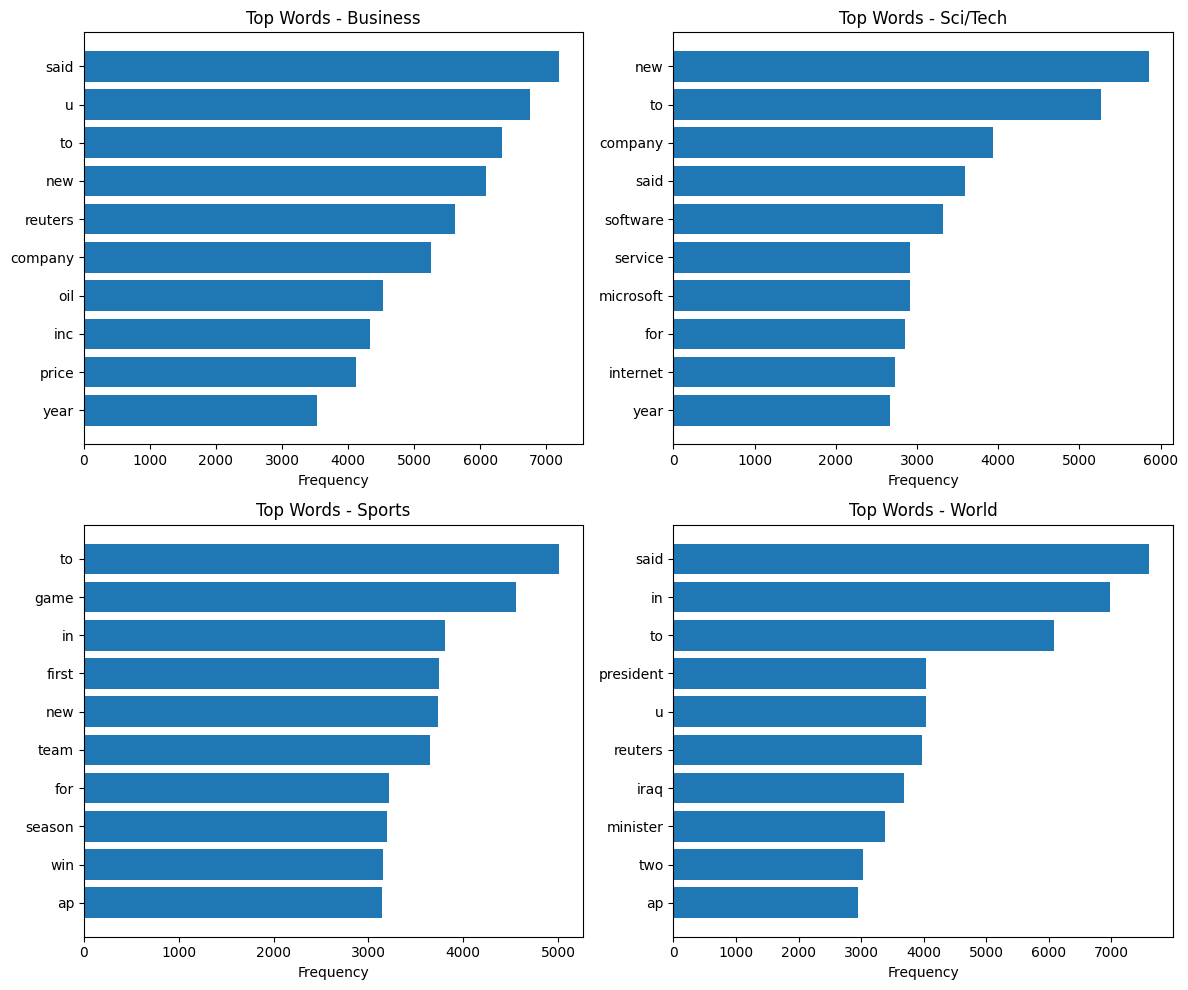

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

categories = df_train['category'].unique()  

n_words = 10  # number of top words per category

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, category in enumerate(categories):
    
    text = " ".join(df_train[df_train['category'] == category]['text'])
    words = text.split()
    
    word_counts = Counter(words)
    most_common = word_counts.most_common(n_words)
    
    words_plot = [w[0] for w in most_common]
    counts_plot = [w[1] for w in most_common]
    
    axes[i].barh(words_plot[::-1], counts_plot[::-1])
    axes[i].set_title(f"Top Words - {category}")
    axes[i].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

### TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features = 3000,
    ngram_range = (1,2)
)

X_train = tfidf.fit_transform(df_train['text'])
X_test = tfidf.transform(df_test['text'])

y_train = df_train['Class Index']
y_test = df_test['Class Index']

### Model training

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [13]:
# SVM 
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

## Model evaluation

In [14]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.8980263157894737

Classification Report:

              precision    recall  f1-score   support

           1       0.91      0.89      0.90      1900
           2       0.94      0.97      0.96      1900
           3       0.86      0.86      0.86      1900
           4       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9001315789473684

Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.89      0.91      1900
           2       0.94      0.97      0.96      1900
           3       0.87      0.87      0.87      1900
           4       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



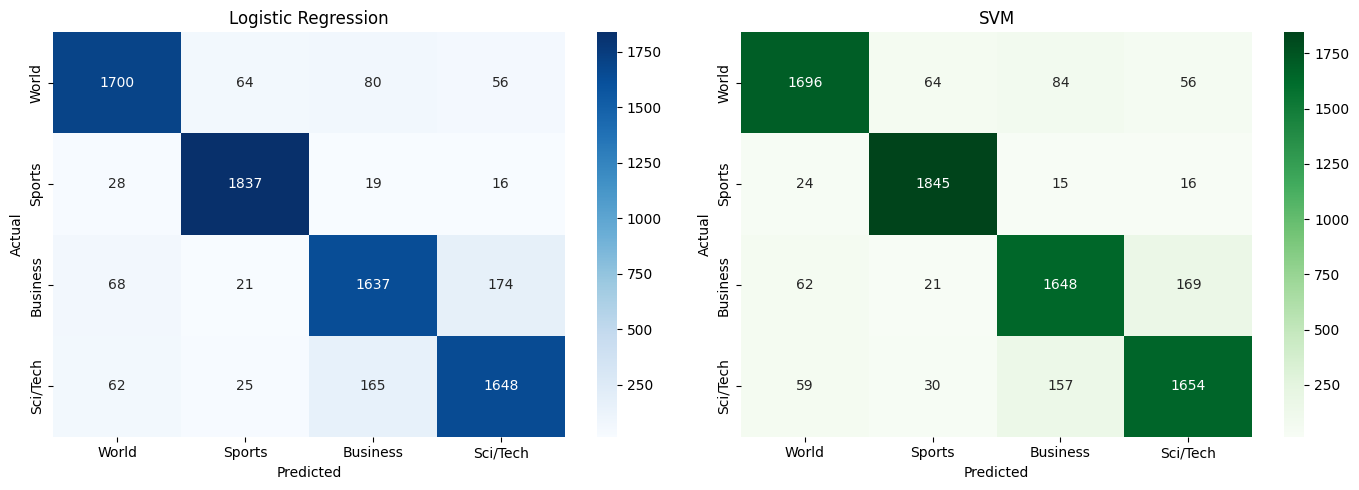

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_lr = confusion_matrix(y_test, lr_pred)
cm_svm = confusion_matrix(y_test, y_pred_svm)

class_names = ["World", "Sports", "Business", "Sci/Tech"]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Logistic Regression
sns.heatmap(cm_lr, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0])

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# SVM
sns.heatmap(cm_svm, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1])

axes[1].set_title("SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [16]:
def predict_news(text, model, vectorizer):
    # Clean text
    cleaned = clean_text(text)
    
    # Vectorize
    vectorized = tfidf.transform([cleaned])
    
    # Predict
    prediction = model.predict(vectorized)[0]
    
    # Convert to label
    category = class_mapping[prediction]
    return category


sample_text = "Apple releases new AI-powered iPhone with advanced chip technology"
prediction = predict_news(sample_text, svm_model, tfidf)

print("Predicted Category:", prediction)

Predicted Category: Sci/Tech


In [17]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']